# FIFA WC 2026 DATASET 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(r"C:\Abhishree\Projects_GitHubLinked\datasets\Titanic\Titanic-Dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
df.shape

(891, 12)

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


Step 1 : what does one row represent?

In [10]:
""" 
Each row represents the information of the one passenger.
"""

' \nEach row represents the information of the one passenger.\n'


Step 2 : Think about missing values. ( don't think how do I fill these.) 
why might someone's AGE be missing? could the recorder have 
* forgotten it?
* not known it?
* intentionally left it blank?
is age an important feature?

In [11]:
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


## HANDLING MISSING VALUES

<Axes: xlabel='Age', ylabel='Count'>

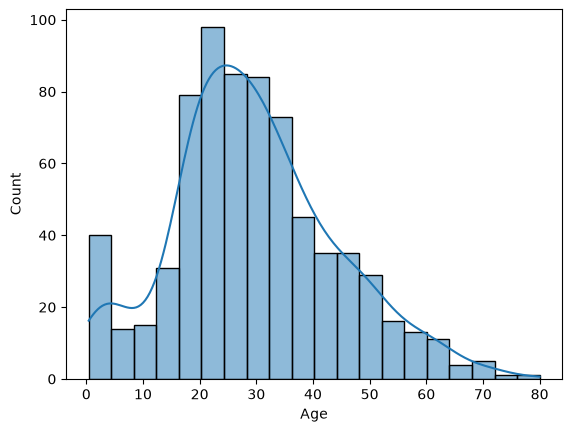

In [12]:
sns.histplot(df['Age'],kde=True)

In [13]:
# I want to extract Mr , Mrs from name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.',expand=False) 
print(df['Title'].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [14]:
df['Title'] = df['Title'].replace(['Mlle','Ms'],'Miss')
df['Title'] = df['Title'].replace('Mme','Ms')
df['Title'] = df['Title'].replace(['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'],'Rare')

In [15]:
df['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       125
Master     40
Rare       23
Ms          1
Name: count, dtype: int64

<Axes: xlabel='Pclass', ylabel='Age'>

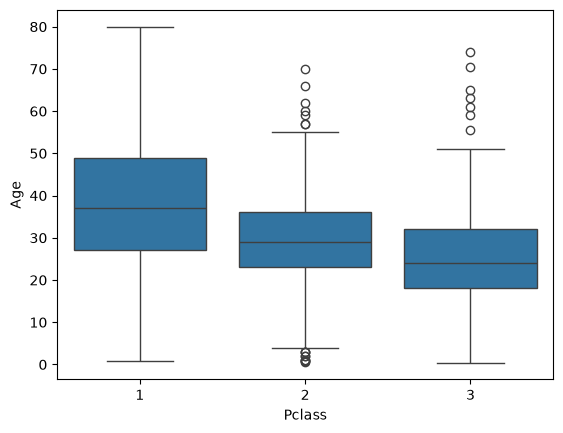

In [16]:
sns.boxplot(y=df['Age'], x= df['Pclass'])

<Axes: xlabel='Title', ylabel='Age'>

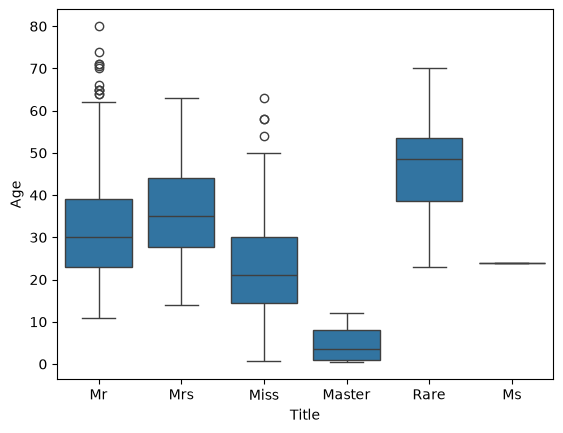

In [17]:
sns.boxplot(y = df['Age'], x = df['Title'])

<Axes: xlabel='Age', ylabel='Count'>

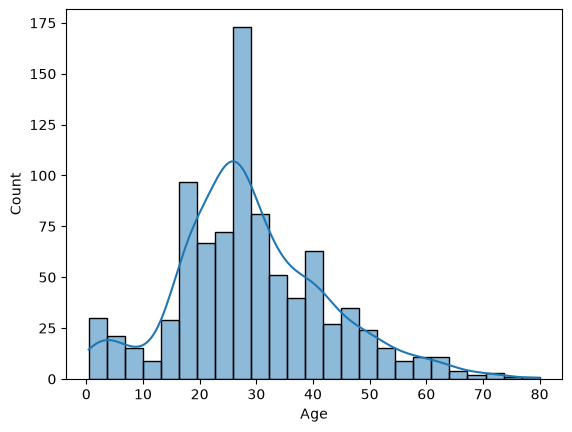

In [18]:
# calculating the median age for each title group and use it to fill the missing values in Age
# Make sure to run this on a freshly loaded dataframe!
df['Age'] = df['Age'].fillna(df.groupby(['Title','Pclass'])['Age'].transform('median'))
df['Age'] = df['Age'].fillna(df.groupby('Title')['Age'].transform('median'))
df['Age'] = df['Age'].fillna(df['Age'].median())
# Now plot it!
sns.histplot(df['Age'], kde=True)

CABIN: 687 out of 891 values are missing. 
should we keep it? drop it? investigate it first? 

In [19]:
# CABIN HAS SOME NULL VALUES.
df['Cabin'].isnull().mean() *100
# 77% missing values. 
# if we fill we will be making things up, so let's drop it entirely.
# before droppping lets take out the useful information and then drop.
df['Cabin'].head(15)
#  useful info is the C deck G deck.

0      NaN
1      C85
2      NaN
3     C123
4      NaN
5      NaN
6      E46
7      NaN
8      NaN
9      NaN
10      G6
11    C103
12     NaN
13     NaN
14     NaN
Name: Cabin, dtype: str

In [20]:
df['Deck'] = df['Cabin'].str[0]
df['Deck']

0      NaN
1        C
2      NaN
3        C
4      NaN
      ... 
886    NaN
887      B
888    NaN
889      C
890    NaN
Name: Deck, Length: 891, dtype: str

In [21]:
df['Deck'] = df['Deck'].fillna('Unknown')

In [22]:
df.drop(columns= 'Cabin', inplace=True)

In [85]:
df.head(2)

,Survived,Pclass,is_female,Age,SibSp,Parch,Fare,Title,Deck,Embarked_Q,Embarked_S,FamilySize,Age_category_Teenager,Age_category_Adult,Age_category_Senior,FareBin
0,0,3,0,-0.529748,1,0,-0.502445,Mr,0,0,1,0.05916,0,1,0,Low
1,1,1,1,0.655885,1,0,0.786845,Mrs,1,0,0,0.05916,0,1,0,VeryHigh


EMBARKED: only 2 values are missing. 
* Delete those 2 rows? 
* fill them?
* ignore them?

In [24]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0]) 

In [25]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Title          0
Deck           0
dtype: int64

## LABEL ENCODING

In [27]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [28]:
df['Sex'] = df['Sex'].map({'male':0,'female':1})

In [29]:
df['Sex'].value_counts()

Sex
0    577
1    314
Name: count, dtype: int64

In [30]:
df.rename(columns={'Sex':'is_female'},inplace=True)

In [31]:
df.head(2)

,PassengerId,Survived,Pclass,Name,is_female,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,Deck
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S,Mr,Unknown
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C,Mrs,C


In [32]:
df['Embarked'].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [33]:
df = pd.get_dummies(df,columns=['Embarked'],drop_first=True)

In [34]:
df.head(2)

,PassengerId,Survived,Pclass,Name,is_female,Age,SibSp,Parch,Ticket,Fare,Title,Deck,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,Mr,Unknown,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,Mrs,C,False,False


In [35]:
df['Embarked_Q'].value_counts()

Embarked_Q
False    814
True      77
Name: count, dtype: int64

In [36]:
df['Embarked_Q'] = df['Embarked_Q'].map({False:0,True:1})

In [37]:
df.head(3)

,PassengerId,Survived,Pclass,Name,is_female,Age,SibSp,Parch,Ticket,Fare,Title,Deck,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,Mr,Unknown,0,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,Mrs,C,0,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,Miss,Unknown,0,True


In [38]:
df['Embarked_S'] = df['Embarked_S'].map({False:0,True:1})

In [39]:
df.head(3)

,PassengerId,Survived,Pclass,Name,is_female,Age,SibSp,Parch,Ticket,Fare,Title,Deck,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,Mr,Unknown,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,Mrs,C,0,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,Miss,Unknown,0,1


## understading how the data is related in between (timpass)

<Axes: xlabel='Survived', ylabel='count'>

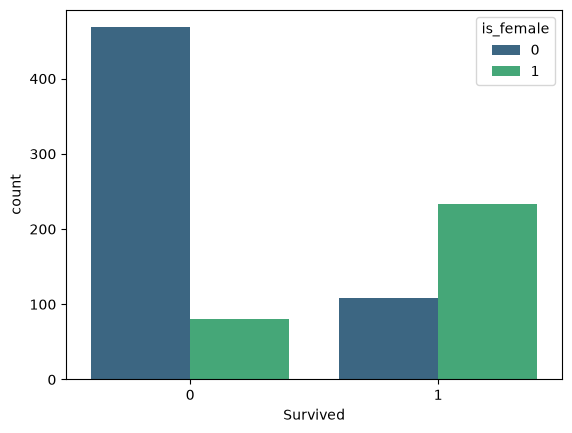

In [42]:
sns.countplot(x=df['Survived'],hue=df['is_female'],palette='viridis')

<Axes: xlabel='Survived', ylabel='count'>

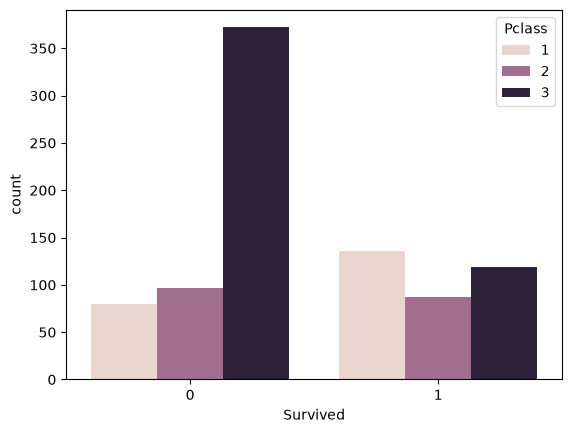

In [43]:
sns.countplot(x=df['Survived'], hue=df['Pclass'])

## FEATURE ENGINEERING 

In [86]:
df.head(3)

,Survived,Pclass,is_female,Age,SibSp,Parch,Fare,Title,Deck,Embarked_Q,Embarked_S,FamilySize,Age_category_Teenager,Age_category_Adult,Age_category_Senior,FareBin
0,0,3,0,-0.529748,1,0,-0.502445,Mr,0,0,1,0.059160,0,1,0,Low
1,1,1,1,0.655885,1,0,0.786845,Mrs,1,0,0,0.059160,0,1,0,VeryHigh
2,1,3,1,-0.233340,0,0,-0.488854,Miss,0,0,1,-0.560975,0,1,0,Med


In [45]:
df['FamilySize'] = df['SibSp']+df['Parch']+1

In [46]:
df.head()

,PassengerId,Survived,Pclass,Name,is_female,Age,SibSp,Parch,Ticket,Fare,Title,Deck,Embarked_Q,Embarked_S,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,Mr,Unknown,0,1,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,Mrs,C,0,0,2
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,Miss,Unknown,0,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,Mrs,C,0,1,2
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,Mr,Unknown,0,1,1


## BINNING

In [47]:
df['Age_category'] = pd.cut(
    df['Age'],
    bins= [0,12,19,64,120],
    labels=['Child','Teenager','Adult','Senior']
)

In [48]:
df.head(2)

,PassengerId,Survived,Pclass,Name,is_female,Age,SibSp,Parch,Ticket,Fare,Title,Deck,Embarked_Q,Embarked_S,FamilySize,Age_category
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,Mr,Unknown,0,1,2,Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,Mrs,C,0,0,2,Adult


In [49]:
df['Age_category'].value_counts()

Age_category
Adult       679
Teenager    128
Child        73
Senior       11
Name: count, dtype: int64

In [50]:
df = pd.get_dummies(df, columns=['Age_category'], drop_first=True)

In [51]:
df.head(2)

,PassengerId,Survived,Pclass,Name,is_female,Age,SibSp,Parch,Ticket,Fare,Title,Deck,Embarked_Q,Embarked_S,FamilySize,Age_category_Teenager,Age_category_Adult,Age_category_Senior
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,Mr,Unknown,0,1,2,False,True,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,Mrs,C,0,0,2,False,True,False


In [52]:
df['Age_category_Adult'].value_counts()

Age_category_Adult
True     679
False    212
Name: count, dtype: int64

In [53]:
df['Age_category_Adult'] = df['Age_category_Adult'].map({True:1, False:0})

In [54]:
df.head(2)

,PassengerId,Survived,Pclass,Name,is_female,Age,SibSp,Parch,Ticket,Fare,Title,Deck,Embarked_Q,Embarked_S,FamilySize,Age_category_Teenager,Age_category_Adult,Age_category_Senior
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,Mr,Unknown,0,1,2,False,1,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,Mrs,C,0,0,2,False,1,False


In [55]:
df['Age_category_Senior'].value_counts()

Age_category_Senior
False    880
True      11
Name: count, dtype: int64

In [56]:
df['Age_category_Senior'] = df['Age_category_Senior'].map({False:0,True:1})

In [57]:
df['Age_category_Teenager'] = df['Age_category_Teenager'].map({False:0,True:1})

In [58]:
df.head(2)

,PassengerId,Survived,Pclass,Name,is_female,Age,SibSp,Parch,Ticket,Fare,Title,Deck,Embarked_Q,Embarked_S,FamilySize,Age_category_Teenager,Age_category_Adult,Age_category_Senior
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,Mr,Unknown,0,1,2,0,1,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,Mrs,C,0,0,2,0,1,0


In [59]:
df['Fare'].value_counts()

Fare
8.0500     43
13.0000    42
7.8958     38
7.7500     34
26.0000    31
           ..
13.8583     1
50.4958     1
5.0000      1
9.8458      1
10.5167     1
Name: count, Length: 248, dtype: int64

In [60]:
df.drop(columns=['Name'],inplace= True)

In [61]:
df.drop(columns= ['PassengerId'],inplace=True)

In [62]:
df.head(1)

,Survived,Pclass,is_female,Age,SibSp,Parch,Ticket,Fare,Title,Deck,Embarked_Q,Embarked_S,FamilySize,Age_category_Teenager,Age_category_Adult,Age_category_Senior
0,0,3,0,22.0,1,0,A/5 21171,7.25,Mr,Unknown,0,1,2,0,1,0


In [63]:
df.drop(columns= ['Ticket'],inplace= True)

In [64]:
df.head(1)

,Survived,Pclass,is_female,Age,SibSp,Parch,Fare,Title,Deck,Embarked_Q,Embarked_S,FamilySize,Age_category_Teenager,Age_category_Adult,Age_category_Senior
0,0,3,0,22.0,1,0,7.25,Mr,Unknown,0,1,2,0,1,0


In [65]:
df['Deck'].value_counts()

Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

In [66]:
df['Deck'] = df['Deck'].apply(lambda x: 0 if x=='Unknown' else 1)

In [67]:
df['Deck'].value_counts()

Deck
0    687
1    204
Name: count, dtype: int64

In [68]:
df.head(1)

,Survived,Pclass,is_female,Age,SibSp,Parch,Fare,Title,Deck,Embarked_Q,Embarked_S,FamilySize,Age_category_Teenager,Age_category_Adult,Age_category_Senior
0,0,3,0,22.0,1,0,7.25,Mr,0,0,1,2,0,1,0


In [69]:
df['FareBin'] = pd.qcut(df['Fare'], 4, labels=['Low','Med','High','VeryHigh'])

In [70]:
df.head(20)

,Survived,Pclass,is_female,Age,SibSp,Parch,Fare,Title,Deck,Embarked_Q,Embarked_S,FamilySize,Age_category_Teenager,Age_category_Adult,Age_category_Senior,FareBin
0,0,3,0,22.0,1,0,7.2500,Mr,0,0,1,2,0,1,0,Low
1,1,1,1,38.0,1,0,71.2833,Mrs,1,0,0,2,0,1,0,VeryHigh
2,1,3,1,26.0,0,0,7.9250,Miss,0,0,1,1,0,1,0,Med
3,1,1,1,35.0,1,0,53.1000,Mrs,1,0,1,2,0,1,0,VeryHigh
4,0,3,0,35.0,0,0,8.0500,Mr,0,0,1,1,0,1,0,Med
5,0,3,0,26.0,0,0,8.4583,Mr,0,1,0,1,0,1,0,Med
6,0,1,0,54.0,0,0,51.8625,Mr,1,0,1,1,0,1,0,VeryHigh
7,0,3,0,2.0,3,1,21.0750,Master,0,0,1,5,0,0,0,High
8,1,3,1,27.0,0,2,11.1333,Mrs,0,0,1,3,0,1,0,Med
9,1,2,1,14.0,1,0,30.0708,Mrs,0,0,0,2,1,0,0,High


## SCALING

<Axes: xlabel='Fare', ylabel='Count'>

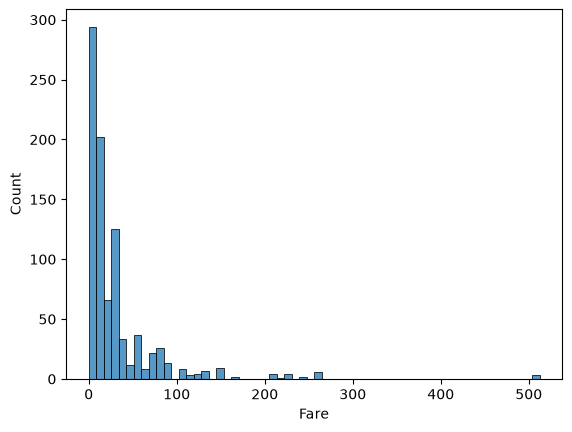

In [74]:
sns.histplot(x=df['Fare'])

<Axes: xlabel='Age', ylabel='Count'>

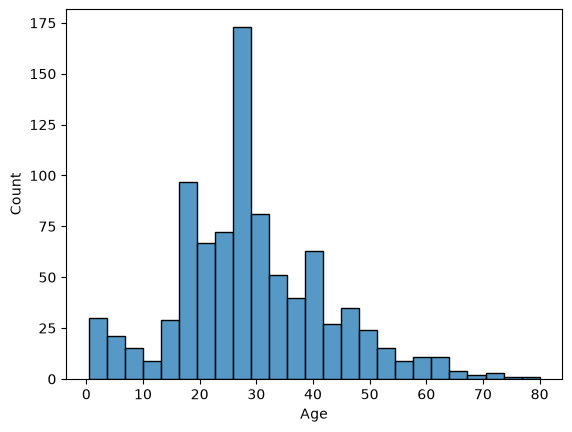

In [77]:
sns.histplot(df['Age'])

<Axes: xlabel='FamilySize', ylabel='Count'>

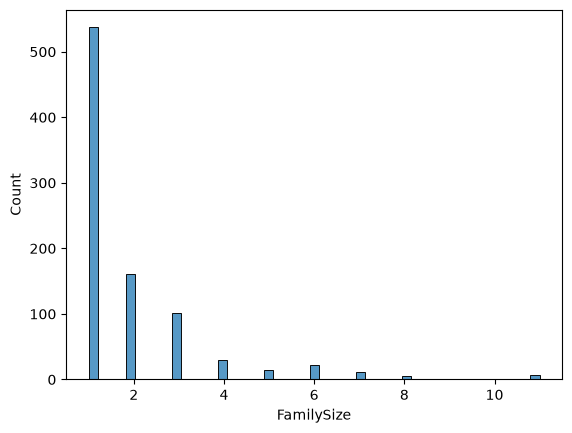

In [81]:
sns.histplot(df['FamilySize'])

In [82]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['Age','Fare','FamilySize']] = scaler.fit_transform(df[['Age','Fare','FamilySize']])

In [84]:
df.head(20)

,Survived,Pclass,is_female,Age,SibSp,Parch,Fare,Title,Deck,Embarked_Q,Embarked_S,FamilySize,Age_category_Teenager,Age_category_Adult,Age_category_Senior,FareBin
0,0,3,0,-0.529748,1,0,-0.502445,Mr,0,0,1,0.059160,0,1,0,Low
1,1,1,1,0.655885,1,0,0.786845,Mrs,1,0,0,0.059160,0,1,0,VeryHigh
2,1,3,1,-0.233340,0,0,-0.488854,Miss,0,0,1,-0.560975,0,1,0,Med
3,1,1,1,0.433579,1,0,0.420730,Mrs,1,0,1,0.059160,0,1,0,VeryHigh
4,0,3,0,0.433579,0,0,-0.486337,Mr,0,0,1,-0.560975,0,1,0,Med
5,0,3,0,-0.233340,0,0,-0.478116,Mr,0,1,0,-0.560975,0,1,0,Med
6,0,1,0,1.841518,0,0,0.395814,Mr,1,0,1,-0.560975,0,1,0,VeryHigh
7,0,3,0,-2.011789,3,1,-0.224083,Master,0,0,1,1.919564,0,0,0,High
8,1,3,1,-0.159238,0,2,-0.424256,Mrs,0,0,1,0.679295,0,1,0,Med
9,1,2,1,-1.122565,1,0,-0.042956,Mrs,0,0,0,0.059160,1,0,0,High
